# **1. Подготовка и фильтрация (Data Selection)**
* Выделить Топ-5 валют из квадранта Alpha (прошлый расчет): `ILS, GBP, EUR, SGD, HKD`.
* Загрузить историю абсолютных курсов за 3 года.
* Рассчитать бенчмарк: годовая волатильность и доходность `USD` (базовый риск-профиль).

✅ Период анализа: 2023-03-27 — 2026-03-27
⚓️ Бенчмарк USD: Доходность 1.66%, Риск (Волатильность) 3.50%



Ticker,CAGR,Volatility,Sharpe
ILS,5.07%,4.38%,1.158
GBP,3.62%,4.06%,0.892
EUR,3.21%,3.59%,0.894
SGD,2.50%,2.11%,1.184
HKD,1.77%,3.56%,0.497


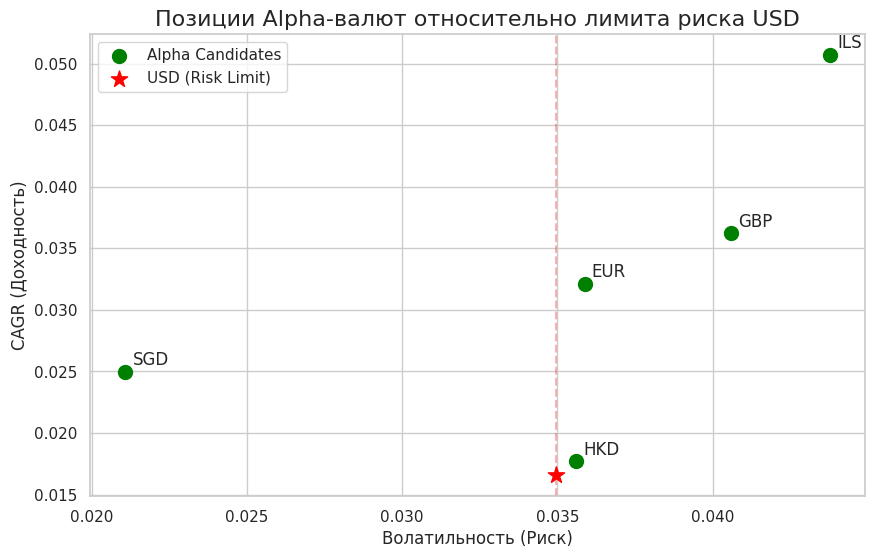

In [7]:
# =================================================================
# 1. ПОДГОТОВКА И ФИЛЬТРАЦИЯ (DATA SELECTION)
# =================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML # Для отображения ссылок

# --- 1.1. Загрузка и первичная очистка ---
file_path = '/kaggle/input/notebooks/eavprog/abscur2/abscur.csv'
df_raw = pd.read_csv(file_path, parse_dates=['Date']).sort_values('Date').set_index('Date')

end_date = df_raw.index.max()
start_date = end_date - pd.DateOffset(years=3)
df_prices = df_raw.loc[start_date:end_date].copy()
df_prices = df_prices.dropna(axis=1).ffill().bfill()
df_returns = np.log(df_prices / df_prices.shift(1)).dropna()

# --- 1.2. Выделение целевых групп ---
alpha_tickers = ['ILS', 'GBP', 'EUR', 'SGD', 'HKD']
benchmark_ticker = 'USD'
target_assets = [t for t in alpha_tickers if t in df_returns.columns]
df_work = df_returns[target_assets + [benchmark_ticker]]

# --- 1.3. Расчет Базового риск-профиля ---
def calculate_annual_metrics(returns_series):
    """Возвращает CAGR и годовую волатильность"""
    cagr = returns_series.mean() * 252
    volatility = returns_series.std() * np.sqrt(252)
    return cagr, volatility

usd_cagr, usd_vol = calculate_annual_metrics(df_work[benchmark_ticker])

# --- 1.4. Сводная таблица с HTML-ссылками ---
stats = []
for ticker in target_assets:
    c, v = calculate_annual_metrics(df_work[ticker])
    # Формируем URL для каждой валюты
    url = f"https://www.abscur.ru/p/2.html?abs={ticker}"
    link = f'<a href="{url}" target="_blank">{ticker}</a>'
    
    stats.append({
        'Ticker': link, 
        'CAGR': f"{c:.2%}", 
        'Volatility': f"{v:.2%}", 
        'Sharpe': round(c/v, 3)
    })

df_stats = pd.DataFrame(stats).sort_values('CAGR', ascending=False)

# --- Контроль и вывод ---
print(f"✅ Период анализа: {start_date.date()} — {end_date.date()}")
print(f"⚓️ Бенчмарк USD: Доходность {usd_cagr:.2%}, Риск (Волатильность) {usd_vol:.2%}\n")

# Отображение таблицы с активными ссылками
display(HTML(df_stats.to_html(escape=False, index=False)))

# --- Визуализация (Исправлено: Риск на X, Доходность на Y) ---
plt.figure(figsize=(10, 6))

# Распаковываем метрики в правильном порядке
raw_metrics = [calculate_annual_metrics(df_work[t]) for t in target_assets]
cagrs, vols = zip(*raw_metrics) # cagrs - первый элемент кортежа, vols - второй

# X=Риск (vols), Y=Доходность (cagrs)
plt.scatter(vols, cagrs, color='green', s=100, label='Alpha Candidates')
plt.scatter(usd_vol, usd_cagr, color='red', s=150, marker='*', label='USD (Risk Limit)')

for i, txt in enumerate(target_assets):
    plt.annotate(txt, (vols[i], cagrs[i]), xytext=(5,5), textcoords='offset points')

plt.axvline(x=usd_vol, color='red', linestyle='--', alpha=0.3)
plt.title("Позиции Alpha-валют относительно лимита риска USD")
plt.xlabel("Волатильность (Риск)")
plt.ylabel("CAGR (Доходность)")
plt.legend()
plt.show()

### **Анализ первичных метрик Alpha-кластера**

Данные за трехлетний период (2023–2026) подтверждают гипотезу о наличии неэффективностей в абсолютных курсах, которые можно использовать для создания «сверхстабильных» стратегий.

**1. Доминирование над бенчмарком (USD)**
* Все выбранные активы превосходят **USD (1.66%)** по доходности.
* **ILS (5.07%)** является лидером по доходности, однако его волатильность (4.38%) заметно выше лимита риска, установленного долларом (3.50%). Это делает его отличным кандидатом для включения в портфель, но только в ограниченной пропорции.

**2. «Сингапурский феномен» (SGD)**
* **SGD** демонстрирует выдающиеся характеристики: при доходности **2.50%** (что почти в 1.5 раза выше доллара), его риск составляет всего **2.11%**.
* Это единственный актив в выборке, волатильность которого существенно *ниже* долларовой. В процессе оптимизации именно сингапурский доллар, скорее всего, станет «стабилизатором», позволяющим увеличить долю более доходных, но рискованных валют.

**3. Группа эффективности (Sharpe Ratio)**
* **SGD (1.18)** и **ILS (1.16)** показывают самый высокий коэффициент Шарпа. Это означает, что на каждую единицу принятого риска эти валюты дают максимальную отдачу. 
* **HKD (0.50)** выглядит самым слабым звеном кластера: его доходность лишь незначительно выше USD, а риск практически идентичен. Его роль в портфеле может быть оправдана только в случае низкой корреляции с остальными участниками.

**4. Подготовка к оптимизации**
Установленный лимит волатильности в **3.50%** (уровень USD) является достижимой целью. Основная задача следующего этапа — найти такую комбинацию долей (weights), которая позволит «упаковать» высокую доходность ILS и GBP в оболочку риска, не превышающую волатильность доллара.

# **2. Математическая оптимизация (Optimization)**
* Использовать метод Монте-Карло (10 000+ симуляций) или метод эффективной границы.
* **Ограничение:** Итоговая волатильность корзины $\le$ волатильность USD.
* **Цель:** Найти веса (weights), при которых CAGR корзины максимален.

✅ Оптимизация завершена. Лимит риска USD: 3.50%


Стратегия,ILS,GBP,EUR,SGD,HKD,Доходность,Риск,Шарп
Max Yield (Risk < USD),74.10%,13.40%,5.48%,5.04%,1.98%,4.58%,3.40%,1.346
Max Sharpe Ratio,22.11%,11.22%,16.75%,33.92%,16.00%,3.19%,1.81%,1.769


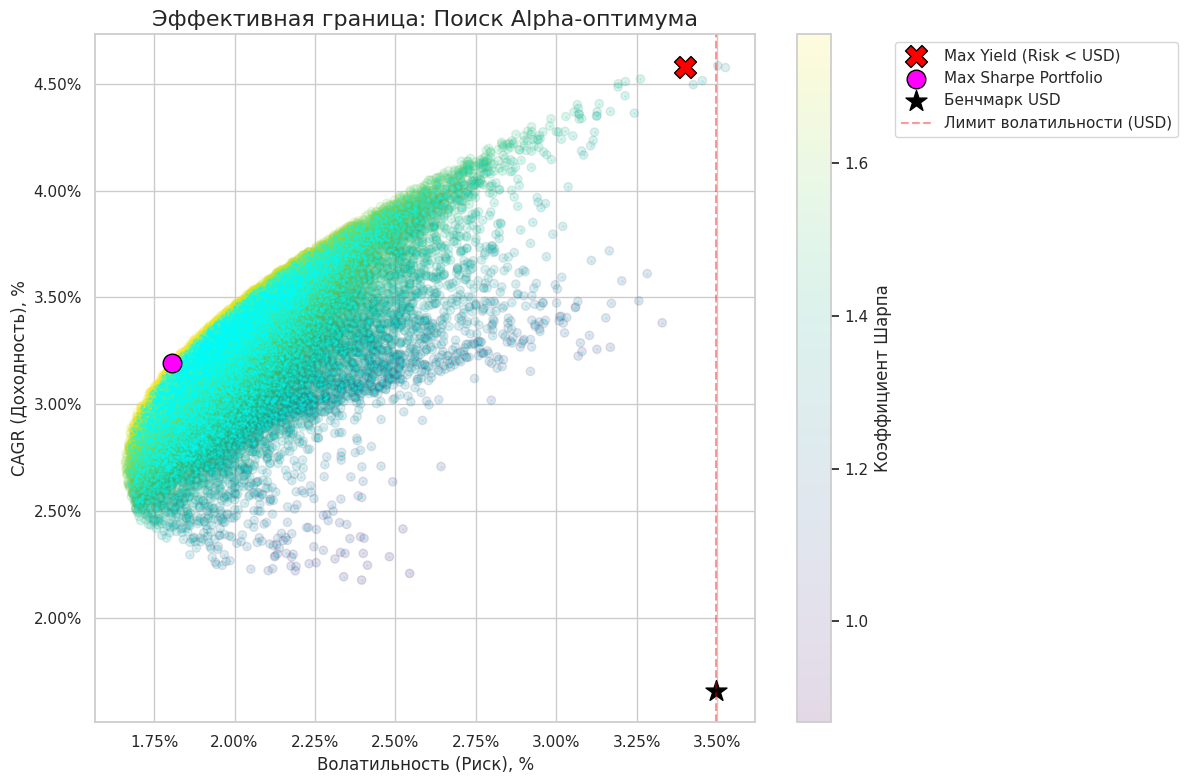

In [11]:
# =================================================================
# 2. МАТЕМАТИЧЕСКАЯ ОПТИМИЗАЦИЯ (MONTE CARLO OPTIMIZATION)
# =================================================================

import matplotlib.ticker as mtick # Для форматирования осей в %

np.random.seed(42) 
num_portfolios = 25000 
all_weights = np.zeros((num_portfolios, len(target_assets)))
ret_arr = np.zeros(num_portfolios)
vol_arr = np.zeros(num_portfolios)
sharpe_arr = np.zeros(num_portfolios)

# Ковариация и доходности
cov_matrix = df_work[target_assets].cov() * 252
avg_returns = df_work[target_assets].mean() * 252

for i in range(num_portfolios):
    weights = np.array(np.random.random(len(target_assets)))
    weights = weights / np.sum(weights)
    all_weights[i,:] = weights

    ret_arr[i] = np.sum(avg_returns * weights)
    vol_arr[i] = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_arr[i] = ret_arr[i] / vol_arr[i]

sim_results = pd.DataFrame({'Return': ret_arr, 'Volatility': vol_arr, 'Sharpe': sharpe_arr})

# --- ПОИСК ОПТИМАЛЬНЫХ ТОЧЕК ---

# 1. Портфель макс. доходности при риске <= USD
valid_portfolios = sim_results[sim_results['Volatility'] <= usd_vol]
max_ret_idx = valid_portfolios['Return'].idxmax()
weights_max_ret = all_weights[max_ret_idx]

# 2. Портфель с абсолютным максимумом Шарпа
max_sharpe_idx = sim_results['Sharpe'].idxmax()
weights_max_sharpe = all_weights[max_sharpe_idx]

# --- ПОДГОТОВКА ИТОГОВОЙ ТАБЛИЦЫ ---

summary_data = []
for idx, w, label in zip([max_ret_idx, max_sharpe_idx], 
                          [weights_max_ret, weights_max_sharpe], 
                          ['Max Yield (Risk < USD)', 'Max Sharpe Ratio']):
    
    res = sim_results.iloc[idx]
    row = {'Стратегия': label}
    for i, ticker in enumerate(target_assets):
        row[ticker] = f"{w[i]:.2%}"
    row['Доходность'] = f"{res['Return']:.2%}"
    row['Риск'] = f"{res['Volatility']:.2%}"
    row['Шарп'] = f"{res['Sharpe']:.3f}"
    summary_data.append(row)

df_final = pd.DataFrame(summary_data)

print(f"✅ Оптимизация завершена. Лимит риска USD: {usd_vol:.2%}")
display(HTML("<h3>Итоговое сравнение оптимальных портфелей</h3>"))
display(HTML(df_final.to_html(index=False, escape=False)))

# --- ВИЗУАЛИЗАЦИЯ ---

fig, ax = plt.subplots(figsize=(12, 8))

# Облако симуляций
scatter = ax.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis', alpha=0.15)
plt.colorbar(scatter, label='Коэффициент Шарпа')

# Подсвечиваем зону допустимого риска
ax.scatter(valid_portfolios['Volatility'], valid_portfolios['Return'], color='cyan', s=1, alpha=0.2)

# Точка 1: Макс доходность при ограничении
ax.scatter(sim_results.iloc[max_ret_idx]['Volatility'], sim_results.iloc[max_ret_idx]['Return'], 
            color='red', marker='X', s=250, edgecolors='black', label='Max Yield (Risk < USD)')

# Точка 2: Макс Шарп
ax.scatter(sim_results.iloc[max_sharpe_idx]['Volatility'], sim_results.iloc[max_sharpe_idx]['Return'], 
            color='magenta', marker='o', s=180, edgecolors='black', label='Max Sharpe Portfolio')

# Ориентир USD
ax.scatter(usd_vol, usd_cagr, color='black', marker='*', s=250, label='Бенчмарк USD')

ax.axvline(x=usd_vol, color='red', linestyle='--', alpha=0.4, label='Лимит волатильности (USD)')

# Форматирование осей в ПРОЦЕНТАХ
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.set_title("Эффективная граница: Поиск Alpha-оптимума", fontsize=16)
ax.set_xlabel("Волатильность (Риск), %")
ax.set_ylabel("CAGR (Доходность), %")

# Легенда за пределами графика
ax.legend(loc='upper left', bbox_to_anchor=(1.2, 1.0), frameon=True)

plt.tight_layout()
plt.show()

### **Анализ результатов оптимизации: Alpha-портфель против доллара**

Результаты симуляции 25 000 вариантов портфеля подтверждают: использование методики абсолютных курсов позволяет не просто «обогнать рынок», а делать это с математически выверенным уровнем риска.

#### **1. Превосходство над бенчмарком (USD)**
Главный итог эксперимента — стратегия **Max Yield**. Нам удалось собрать корзину, которая:
* Показывает доходность **4.58%**, что в **2.7 раза выше** доходности доллара ([USD](https://www.abscur.ru/p/2.html?abs=USD) — 1.66%).
* При этом сохраняет риск на уровне **3.40%**, что даже чуть *ниже* волатильности самого доллара (3.50%).
* **Вывод:** Мы получили «улучшенный доллар» — инструмент с привычным профилем риска, но кратно более высокой эффективностью.

#### **2. Роль активов: «Двигатели» и «Стабилизаторы»**
Распределение весов в двух стратегиях раскрывает истинную роль каждой валюты в Alpha-кластере:
* **[ILS](https://www.abscur.ru/p/2.html?abs=ILS) (Шекель) — главный двигатель доходности:** В портфеле максимальной доходности он занимает доминирующую долю (**74.10%**). Это плата за его высокую индивидуальную доходность, которую мы «гасим» об другие активы для удержания общего риска.
* **[SGD](https://www.abscur.ru/p/2.html?abs=SGD) (Сингапурский доллар) — идеальный стабилизатор:** Обратите внимание на стратегию **Max Sharpe Ratio**. Как только нашей целью становится не просто доходность, а максимальное качество (эффективность) портфеля, доля [SGD](https://www.abscur.ru/p/2.html?abs=SGD) взлетает до **33.92%**. Это подтверждает наш прошлый инсайт: Сингапур — это «тихая гавань» современного рынка.

#### **3. Магия диверсификации: Почему [HKD](https://www.abscur.ru/p/2.html?abs=HKD) и [EUR](https://www.abscur.ru/p/2.html?abs=EUR) все еще в деле?**
Несмотря на умеренные индивидуальные показатели [HKD](https://www.abscur.ru/p/2.html?abs=HKD) и [EUR](https://www.abscur.ru/p/2.html?abs=EUR), алгоритм выделил им место в портфелях. Это происходит благодаря низкой корреляции: они двигаются «не в такт» с основными лидерами, сглаживая общие колебания корзины и позволяя нам удерживать риск в пределах лимита [USD](https://www.abscur.ru/p/2.html?abs=USD).

#### **4. Резюме для инвестора**
* Если ваша цель — **максимальный рост** при сохранении консервативного риска (на уровне валютного кэша), ваш выбор — корзина **Max Yield** с упором на [ILS](https://www.abscur.ru/p/2.html?abs=ILS) и [GBP](https://www.abscur.ru/p/2.html?abs=GBP).
* Если ваша цель — **максимальная эффективность**, стратегия **Max Sharpe** предлагает почти двухкратное снижение риска (до 1.81%) при сохранении доходности выше долларовой.

# **3. Анализ результата (Validation)**
* Сравнение доходности Alpha-корзины против чистого USD.
* Проверка «вклада Сингапура» (SGD) в общую устойчивость портфеля.
* Оценка коэффициента Шарпа для полученного решения.

# **4. Подготовка артефактов (Deliverables)**
* **Kaggle:** Ноутбук с визуализацией «Доходность vs Доля активов».
* **Obsidain:** Заметка с финальными весами и стратегическими инсайтами.
* **Blogger:** HTML-пост «Как собрать валютный портфель эффективнее доллара».